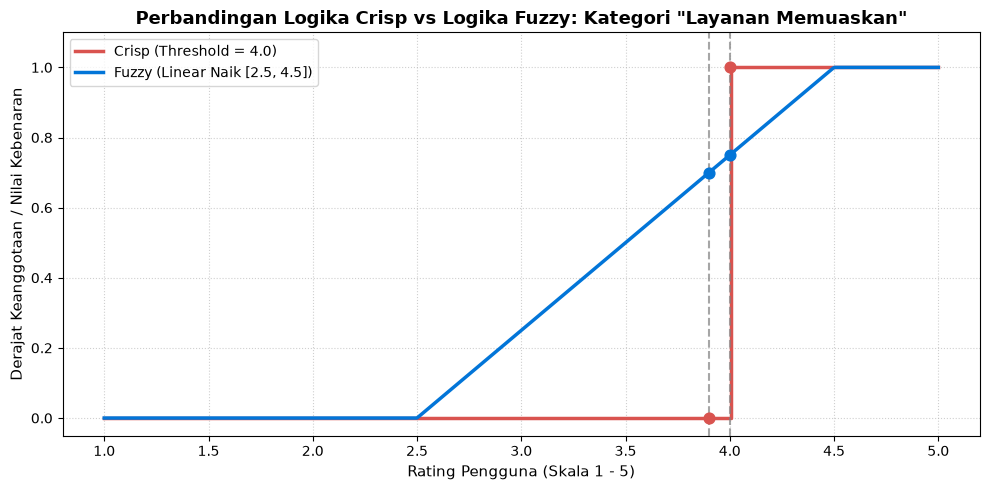

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. DEFINISI FUNGSI KARAKTERISTIK CRISP
# ==========================================================
def crisp_memuaskan(rating, threshold=4.0):
    """
    Fungsi karakteristik crisp.
    Mengembalikan 1 jika rating >= threshold, selain itu 0.
    """
    return np.where(rating >= threshold, 1.0, 0.0)


# ==========================================================
# 2. DEFINISI FUNGSI KEANGGOTAAN FUZZY
# ==========================================================
def fuzzy_memuaskan(rating, a=2.5, b=4.5):
    """
    Fungsi keanggotaan fuzzy linear naik.
    - x <= a       : derajat 0
    - a <= x <= b  : derajat (x - a) / (b - a)
    - x >= b       : derajat 1
    """
    derajat = (rating - a) / (b - a)
    return np.clip(derajat, 0.0, 1.0)


# ==========================================================
# 3. GENERASI DATA SEMESTA PEMBICARAAN
# ==========================================================
# Domain rating layanan dari 1.0 sampai 5.0
ratings = np.linspace(1.0, 5.0, 500)

y_crisp = crisp_memuaskan(ratings, threshold=4.0)
y_fuzzy = fuzzy_memuaskan(ratings, a=2.5, b=4.5)


# ==========================================================
# 4. VISUALISASI PERBANDINGAN
# ==========================================================
plt.figure(figsize=(10, 5))

# Plot Logika Crisp
plt.step(ratings, y_crisp, label='Crisp (Threshold = 4.0)', 
         color='#d9534f', linewidth=2.5, where='post')

# Plot Logika Fuzzy
plt.plot(ratings, y_fuzzy, label='Fuzzy (Linear Naik [2.5, 4.5])', 
         color='#0275d8', linewidth=2.5)

# Penanda titik batas kritis
plt.axvline(x=3.9, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=4.0, color='gray', linestyle='--', alpha=0.7)
plt.scatter([3.9, 4.0], [crisp_memuaskan(3.9), crisp_memuaskan(4.0)], 
            color='#d9534f', zorder=5, s=60)
plt.scatter([3.9, 4.0], [fuzzy_memuaskan(3.9), fuzzy_memuaskan(4.0)], 
            color='#0275d8', zorder=5, s=60)

plt.title('Perbandingan Logika Crisp vs Logika Fuzzy: Kategori "Layanan Memuaskan"', fontsize=13, fontweight='bold')
plt.xlabel('Rating Pengguna (Skala 1 - 5)', fontsize=11)
plt.ylabel('Derajat Keanggotaan / Nilai Kebenaran', fontsize=11)
plt.ylim(-0.05, 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

# Simpan dan tampilkan grafik
plt.savefig('visualisasi_crisp_vs_fuzzy.png', dpi=300)
plt.show()

In [3]:
test_values = [3.8, 3.9, 3.99, 4.0, 4.01, 4.2]

print(f"{'Rating':<8} | {'Crisp':<8} | {'Fuzzy mu(x)':<12} | {'Interpretasi Fuzzy'}")
print("-" * 55)
for val in test_values:
    c_val = float(crisp_memuaskan(val))
    f_val = float(fuzzy_memuaskan(val))
    interpretasi = f"Tingkat pemenuhan {f_val*100:.1f}%"
    print(f"{val:<8.2f} | {c_val:<8.1f} | {f_val:<12.3f} | {interpretasi}")

Rating   | Crisp    | Fuzzy mu(x)  | Interpretasi Fuzzy
-------------------------------------------------------
3.80     | 0.0      | 0.650        | Tingkat pemenuhan 65.0%
3.90     | 0.0      | 0.700        | Tingkat pemenuhan 70.0%
3.99     | 0.0      | 0.745        | Tingkat pemenuhan 74.5%
4.00     | 1.0      | 0.750        | Tingkat pemenuhan 75.0%
4.01     | 1.0      | 0.755        | Tingkat pemenuhan 75.5%
4.20     | 1.0      | 0.850        | Tingkat pemenuhan 85.0%


       SISTEM LAYANAN MEMUASKAN
       PERBANDINGAN CRISP, FUZZY LINEAR DAN SIGMOID
Rating       | Crisp      | Linear       | Sigmoid     
--------------------------------------------------------------------------------
1.0          | 0.000      | 0.000        | 0.007       
2.0          | 0.000      | 0.000        | 0.047       
2.5          | 0.000      | 0.000        | 0.119       
3.0          | 0.000      | 0.250        | 0.269       
3.5          | 0.000      | 0.500        | 0.500       
4.0          | 1.000      | 0.750        | 0.731       
4.5          | 1.000      | 1.000        | 0.881       
5.0          | 1.000      | 1.000        | 0.953       


       CONTOH PERHITUNGAN FUZZY SIGMOID
x = 2.5  ->  μ(x) = 0.119
x = 3.0  ->  μ(x) = 0.269
x = 3.5  ->  μ(x) = 0.500
x = 4.0  ->  μ(x) = 0.731
x = 4.5  ->  μ(x) = 0.881


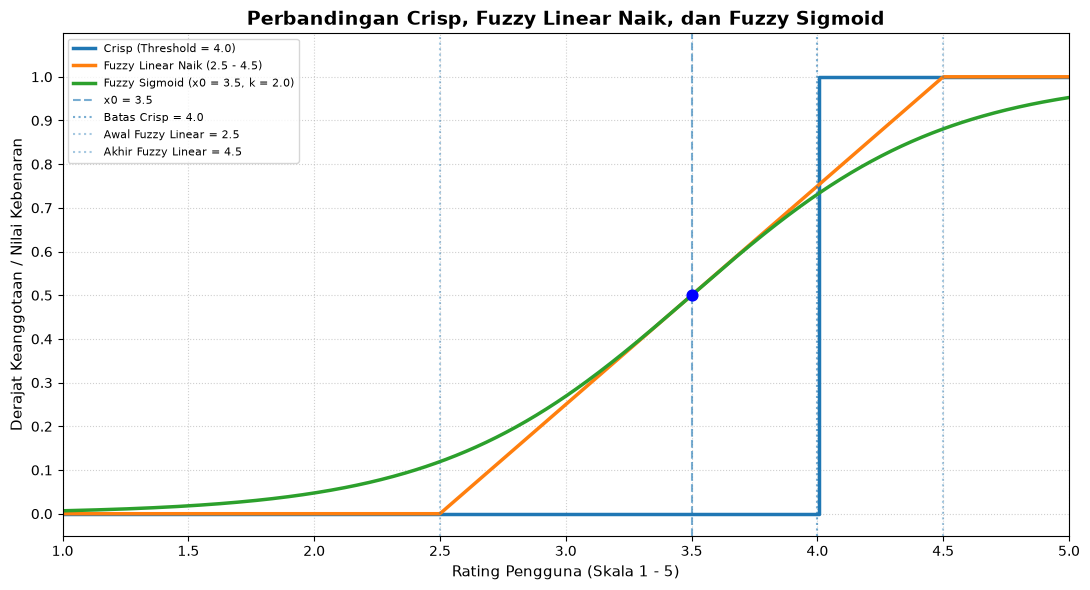

In [27]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# SISTEM LAYANAN MEMUASKAN
# ==========================================================
#
# Semesta pembicaraan : 1 <= x <= 5 (Rating Pengguna)
#
# CRISP:
#   x < 4  -> 0 (Tidak Memuaskan)
#   x >= 4 -> 1 (Memuaskan)
#
# FUZZY LINEAR NAIK:
#   x < 2.5         -> 0
#   2.5 <= x <= 4.5 -> (x - 2.5) / (4.5 - 2.5)
#   x > 4.5         -> 1
#
# FUZZY SIGMOID:
#   μ(x) = 1 / (1 + e^(-k(x - x0)))
#
#   x0 = 3.5
#   k  = 2.0
#
# ==========================================================


# ==========================================================
# 1. FUNGSI CRISP
# ==========================================================

def crisp_memuaskan(rating, threshold=4.0):
    """
    Fungsi Crisp.

    Jika rating >= 4:
        nilai = 1 (Memuaskan)

    Jika rating < 4:
        nilai = 0 (Tidak Memuaskan)
    """

    return np.where(
        rating >= threshold,
        1.0,
        0.0
    )


# ==========================================================
# 2. FUNGSI FUZZY LINEAR NAIK
# ==========================================================

def fuzzy_linear(rating, a=2.5, b=4.5):
    """
    Fungsi keanggotaan Fuzzy Linear Naik.

    Jika rating < 2.5:
        μ(x) = 0

    Jika 2.5 <= rating <= 4.5:
        μ(x) = (x - 2.5) / (4.5 - 2.5)

    Jika rating > 4.5:
        μ(x) = 1
    """

    derajat = (rating - a) / (b - a)

    return np.clip(
        derajat,
        0.0,
        1.0
    )


# ==========================================================
# 3. FUNGSI FUZZY SIGMOID
# ==========================================================

def fuzzy_sigmoid(rating, x0=3.5, k=2.0):
    """
    Fungsi keanggotaan Fuzzy Sigmoid.

    Rumus:
        μ(x) = 1 / (1 + e^(-k(x - x0)))

    x0 = 3.5
    k  = 2.0
    """

    return 1 / (
        1 + np.exp(
            -k * (rating - x0)
        )
    )


# ==========================================================
# 4. DATA PENGUJIAN
# ==========================================================

data_uji = [
    1.0,
    2.0,
    2.5,
    3.0,
    3.5,
    4.0,
    4.5,
    5.0
]


# ==========================================================
# 5. MENAMPILKAN TABEL PERBANDINGAN
# ==========================================================

print("=" * 80)
print("       SISTEM LAYANAN MEMUASKAN")
print("       PERBANDINGAN CRISP, FUZZY LINEAR DAN SIGMOID")
print("=" * 80)

print(
    f"{'Rating':<12} | "
    f"{'Crisp':<10} | "
    f"{'Linear':<12} | "
    f"{'Sigmoid':<12}"
)

print("-" * 80)


for rating in data_uji:

    crisp = float(
        crisp_memuaskan(
            rating,
            threshold=4.0
        )
    )

    linear = float(
        fuzzy_linear(
            rating,
            a=2.5,
            b=4.5
        )
    )

    sigmoid = float(
        fuzzy_sigmoid(
            rating,
            x0=3.5,
            k=2.0
        )
    )

    print(
        f"{rating:<12.1f} | "
        f"{crisp:<10.3f} | "
        f"{linear:<12.3f} | "
        f"{sigmoid:<12.3f}"
    )


# ==========================================================
# 6. PERHITUNGAN MANUAL BEBERAPA DATA
# ==========================================================

print("\n")
print("=" * 80)
print("       CONTOH PERHITUNGAN FUZZY SIGMOID")
print("=" * 80)

contoh = [2.5, 3.0, 3.5, 4.0, 4.5]

for x in contoh:

    sigmoid = float(
        fuzzy_sigmoid(
            x,
            x0=3.5,
            k=2.0
        )
    )

    print(
        f"x = {x:>3.1f}"
        f"  ->  μ(x) = {sigmoid:.3f}"
    )


# ==========================================================
# 7. MEMBUAT DOMAIN UNTUK GRAFIK
# ==========================================================

rating = np.linspace(
    1,
    5,
    500
)


# ==========================================================
# 8. MENGHITUNG NILAI CRISP, LINEAR DAN SIGMOID
# ==========================================================

y_crisp = crisp_memuaskan(
    rating,
    threshold=4.0
)

y_linear = fuzzy_linear(
    rating,
    a=2.5,
    b=4.5
)

y_sigmoid = fuzzy_sigmoid(
    rating,
    x0=3.5,
    k=2.0
)


# ==========================================================
# 9. MEMBUAT GRAFIK
# ==========================================================

plt.figure(
    figsize=(11, 6)
)


# ----------------------------------------------------------
# Grafik Crisp
# ----------------------------------------------------------

plt.step(
    rating,
    y_crisp,
    where="post",
    linewidth=2.5,
    label="Crisp (Threshold = 4.0)"
)


# ----------------------------------------------------------
# Grafik Fuzzy Linear Naik
# ----------------------------------------------------------

plt.plot(
    rating,
    y_linear,
    linewidth=2.5,
    label="Fuzzy Linear Naik (2.5 - 4.5)"
)


# ----------------------------------------------------------
# Grafik Fuzzy Sigmoid
# ----------------------------------------------------------

plt.plot(
    rating,
    y_sigmoid,
    linewidth=2.5,
    label="Fuzzy Sigmoid (x0 = 3.5, k = 2.0)"
)


# ==========================================================
# 10. PENANDA TITIK TENGAH SIGMOID
# ==========================================================

plt.axvline(
    x=3.5,
    linestyle="--",
    alpha=0.6,
    label="x0 = 3.5"
)

plt.scatter(
    3.5,
    fuzzy_sigmoid(3.5),
    color="blue",
    s=60,
    zorder=10
)


# ==========================================================
# 11. PENANDA BATAS CRISP
# ==========================================================

plt.axvline(
    x=4.0,
    linestyle=":",
    alpha=0.6,
    label="Batas Crisp = 4.0"
)


# ==========================================================
# 12. PENANDA BATAS FUZZY LINEAR
# ==========================================================

plt.axvline(
    x=2.5,
    linestyle=":",
    alpha=0.4,
    label="Awal Fuzzy Linear = 2.5"
)

plt.axvline(
    x=4.5,
    linestyle=":",
    alpha=0.4,
    label="Akhir Fuzzy Linear = 4.5"
)


# ==========================================================
# 13. JUDUL GRAFIK
# ==========================================================

plt.title(
    "Perbandingan Crisp, Fuzzy Linear Naik, dan Fuzzy Sigmoid",
    fontsize=14,
    fontweight="bold"
)


# ==========================================================
# 14. LABEL SUMBU
# ==========================================================

plt.xlabel(
    "Rating Pengguna (Skala 1 - 5)",
    fontsize=11
)

plt.ylabel(
    "Derajat Keanggotaan / Nilai Kebenaran",
    fontsize=11
)


# ==========================================================
# 15. PENGATURAN SUMBU
# ==========================================================

plt.xlim(
    1,
    5
)

plt.ylim(
    -0.05,
    1.1
)

plt.xticks(
    np.arange(
        1.0,
        5.1,
        0.5
    )
)

plt.yticks(
    np.arange(
        0.0,
        1.1,
        0.1
    )
)


# ==========================================================
# 16. GRID DAN LEGEND
# ==========================================================

plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.legend(
    loc="upper left",
    fontsize=8
)


# ==========================================================
# 17. MERAPIKAN DAN MENYIMPAN GRAFIK
# ==========================================================

plt.tight_layout()

nama_file = "grafik_komparasi_crisp_linear_sigmoid_layanan.png"

plt.savefig(
    nama_file,
    format="png",
    dpi=300,
    bbox_inches="tight"
)


# ==========================================================
# 18. TAMPILKAN GRAFIK
# ==========================================================

plt.show()

       SISTEM PRIORITAS TIKET HELPDESK TI
       PERBANDINGAN CRISP DAN FUZZY
Waktu (Jam)     | Crisp      | Fuzzy μ(x)   | Interpretasi
--------------------------------------------------------------------------------
2.0             | 0.0        | 0.000        | Tidak kritis
4.0             | 0.0        | 0.000        | Tidak kritis
6.0             | 0.0        | 0.250        | Tingkat kritis 25.0%
7.9             | 0.0        | 0.488        | Tingkat kritis 48.8%
8.0             | 1.0        | 0.500        | Tingkat kritis 50.0%
8.1             | 1.0        | 0.512        | Tingkat kritis 51.2%
10.0            | 1.0        | 0.750        | Tingkat kritis 75.0%
12.0            | 1.0        | 1.000        | Sangat kritis
16.0            | 1.0        | 1.000        | Sangat kritis
24.0            | 1.0        | 1.000        | Sangat kritis


       CONTOH PERHITUNGAN FUZZY
x =  4 jam  ->  μ(x) = 0.000
x =  6 jam  ->  μ(x) = 0.250
x =  8 jam  ->  μ(x) = 0.500
x = 10 jam  ->  μ(x) = 0.750

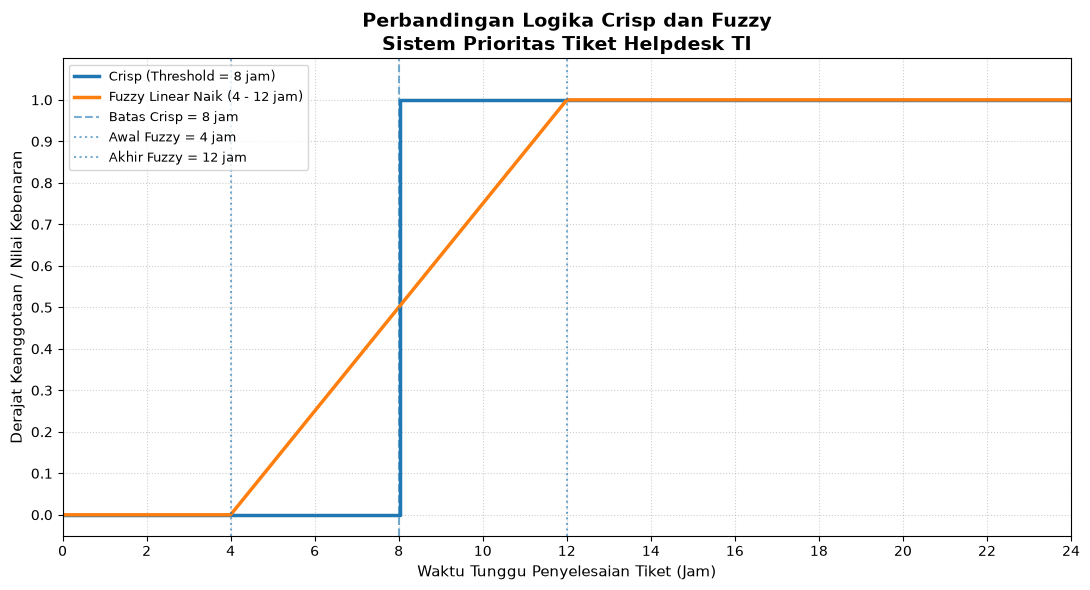

In [28]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# SISTEM PRIORITAS TIKET HELPDESK TI
# ==========================================================
#
# Semesta pembicaraan : 0 <= x <= 24 jam
#
# CRISP:
#   x < 8  -> 0 (Tidak Kritis)
#   x >= 8 -> 1 (Kritis)
#
# FUZZY LINEAR NAIK:
#   x < 4       -> 0
#   4 <= x <= 12 -> (x - 4) / (12 - 4)
#   x > 12      -> 1
#
# ==========================================================


# ==========================================================
# 1. FUNGSI CRISP
# ==========================================================

def crisp_kritis(waktu, threshold=8.0):
    """
    Fungsi Crisp.

    Jika waktu tunggu >= 8 jam:
        nilai = 1 (Kritis)

    Jika waktu tunggu < 8 jam:
        nilai = 0 (Tidak Kritis)
    """

    return np.where(
        waktu >= threshold,
        1.0,
        0.0
    )


# ==========================================================
# 2. FUNGSI FUZZY LINEAR NAIK
# ==========================================================

def fuzzy_kritis(waktu, a=4.0, b=12.0):
    """
    Fungsi keanggotaan Fuzzy Linear Naik.

    Jika waktu < 4 jam:
        μ(x) = 0

    Jika 4 <= waktu <= 12 jam:
        μ(x) = (x - 4) / (12 - 4)

    Jika waktu > 12 jam:
        μ(x) = 1
    """

    derajat = (waktu - a) / (b - a)

    # Membatasi nilai antara 0 dan 1
    return np.clip(
        derajat,
        0.0,
        1.0
    )


# ==========================================================
# 3. DATA PENGUJIAN
# ==========================================================

data_uji = [
    2,
    4,
    6,
    7.9,
    8.0,
    8.1,
    10,
    12,
    16,
    24
]


# ==========================================================
# 4. MENAMPILKAN TABEL PERBANDINGAN
# ==========================================================

print("=" * 80)
print("       SISTEM PRIORITAS TIKET HELPDESK TI")
print("       PERBANDINGAN CRISP DAN FUZZY")
print("=" * 80)

print(
    f"{'Waktu (Jam)':<15} | "
    f"{'Crisp':<10} | "
    f"{'Fuzzy μ(x)':<12} | "
    f"{'Interpretasi'}"
)

print("-" * 80)


for waktu in data_uji:

    # Menghitung nilai Crisp
    crisp = float(
        crisp_kritis(
            waktu,
            threshold=8.0
        )
    )

    # Menghitung nilai Fuzzy
    fuzzy = float(
        fuzzy_kritis(
            waktu,
            a=4.0,
            b=12.0
        )
    )

    # Interpretasi nilai fuzzy
    if fuzzy == 0:
        interpretasi = "Tidak kritis"

    elif fuzzy == 1:
        interpretasi = "Sangat kritis"

    else:
        interpretasi = (
            f"Tingkat kritis {fuzzy * 100:.1f}%"
        )

    print(
        f"{waktu:<15.1f} | "
        f"{crisp:<10.1f} | "
        f"{fuzzy:<12.3f} | "
        f"{interpretasi}"
    )


# ==========================================================
# 5. PERHITUNGAN MANUAL BEBERAPA DATA
# ==========================================================

print("\n")
print("=" * 80)
print("       CONTOH PERHITUNGAN FUZZY")
print("=" * 80)

contoh = [4, 6, 8, 10, 12]

for x in contoh:

    fuzzy = float(
        fuzzy_kritis(
            x,
            a=4.0,
            b=12.0
        )
    )

    print(
        f"x = {x:>2} jam"
        f"  ->  μ(x) = {fuzzy:.3f}"
    )


# ==========================================================
# 6. MEMBUAT DOMAIN UNTUK GRAFIK
# ==========================================================

# Domain waktu tunggu dari 0 sampai 24 jam
waktu = np.linspace(
    0,
    24,
    500
)


# ==========================================================
# 7. MENGHITUNG NILAI CRISP DAN FUZZY UNTUK GRAFIK
# ==========================================================

y_crisp = crisp_kritis(
    waktu,
    threshold=8.0
)

y_fuzzy = fuzzy_kritis(
    waktu,
    a=4.0,
    b=12.0
)


# ==========================================================
# 8. MEMBUAT GRAFIK
# ==========================================================

plt.figure(
    figsize=(11, 6)
)


# ----------------------------------------------------------
# Grafik Crisp
# ----------------------------------------------------------

plt.step(
    waktu,
    y_crisp,
    where="post",
    linewidth=2.5,
    label="Crisp (Threshold = 8 jam)"
)


# ----------------------------------------------------------
# Grafik Fuzzy Linear Naik
# ----------------------------------------------------------

plt.plot(
    waktu,
    y_fuzzy,
    linewidth=2.5,
    label="Fuzzy Linear Naik (4 - 12 jam)"
)


# ==========================================================
# 9. PENANDA BATAS CRISP
# ==========================================================

plt.axvline(
    x=8,
    linestyle="--",
    alpha=0.6,
    label="Batas Crisp = 8 jam"
)


# ==========================================================
# 10. PENANDA BATAS FUZZY
# ==========================================================

# Awal kenaikan fuzzy
plt.axvline(
    x=4,
    linestyle=":",
    alpha=0.6,
    label="Awal Fuzzy = 4 jam"
)

# Akhir kenaikan fuzzy
plt.axvline(
    x=12,
    linestyle=":",
    alpha=0.6,
    label="Akhir Fuzzy = 12 jam"
)


# ==========================================================
# 11. JUDUL GRAFIK
# ==========================================================

plt.title(
    "Perbandingan Logika Crisp dan Fuzzy\n"
    "Sistem Prioritas Tiket Helpdesk TI",
    fontsize=14,
    fontweight="bold"
)


# ==========================================================
# 12. LABEL SUMBU
# ==========================================================

plt.xlabel(
    "Waktu Tunggu Penyelesaian Tiket (Jam)",
    fontsize=11
)

plt.ylabel(
    "Derajat Keanggotaan / Nilai Kebenaran",
    fontsize=11
)


# ==========================================================
# 13. PENGATURAN SUMBU
# ==========================================================

plt.xlim(
    0,
    24
)

plt.ylim(
    -0.05,
    1.1
)

plt.xticks(
    np.arange(
        0,
        25,
        2
    )
)

plt.yticks(
    np.arange(
        0,
        1.1,
        0.1
    )
)


# ==========================================================
# 14. GRID
# ==========================================================

plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)


# ==========================================================
# 15. LEGEND
# ==========================================================

plt.legend(
    loc="upper left",
    fontsize=9
)


# ==========================================================
# 16. MERAPIKAN GRAFIK
# ==========================================================

plt.tight_layout()


# ==========================================================
# 17. SIMPAN GRAFIK DALAM FORMAT PNG
# ==========================================================

nama_file = "grafik_komparasi_crisp_fuzzy_helpdesk.png"

plt.savefig(
    nama_file,
    format="png",
    dpi=300,
    bbox_inches="tight"
)


# ==========================================================
# 18. TAMPILKAN GRAFIK
# ==========================================================

plt.show()